# Time Series Plots Examples

This notebook demonstrates the usage of the TimeSeriesPlots class methods with synthetic time series data and real-world datasets.

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from kvbiii_plots.eda import TimeSeriesPlots

In [2]:
ts_plots = TimeSeriesPlots()
np.random.seed(42)
start_date = datetime(2020, 1, 1)
dates = [start_date + timedelta(days=x) for x in range(730)]

trend = np.linspace(100, 300, 730)
seasonal_yearly = 30 * np.sin(2 * np.pi * np.arange(730) / 365.25)
seasonal_weekly = 10 * np.sin(2 * np.pi * np.arange(730) / 7)
noise = np.random.normal(0, 15, 730)

sales = trend + seasonal_yearly + seasonal_weekly + noise
revenue = sales * (1.2 + 0.1 * np.random.normal(0, 1, 730))
customers = (sales / 10) + 20 + np.random.normal(0, 5, 730)

ts_data = pd.DataFrame({
    'date': dates,
    'sales': np.maximum(sales, 0),
    'revenue': np.maximum(revenue, 0),
    'customers': np.maximum(customers, 0),
    'conversion_rate': np.random.uniform(0.02, 0.08, 730)
})

print("Time series dataset shape:", ts_data.shape)
print("Date range:", ts_data['date'].min(), "to", ts_data['date'].max())
print("\nFirst few rows:")
print(ts_data.head())

Time series dataset shape: (730, 5)
Date range: 2020-01-01 00:00:00 to 2021-12-30 00:00:00

First few rows:
        date       sales     revenue  customers  conversion_rate
0 2020-01-01  107.450712  131.045226  30.052791         0.077638
1 2020-01-02  106.534746  117.418626  24.531983         0.031816
2 2020-01-03  121.045246  150.196001  31.059408         0.077086
3 2020-01-04  129.554862  133.408036  28.702884         0.079689
4 2020-01-05   95.308918  124.179473  26.628275         0.062703


## 1. plot_time_series_mean() - Time Series with Aggregated Mean

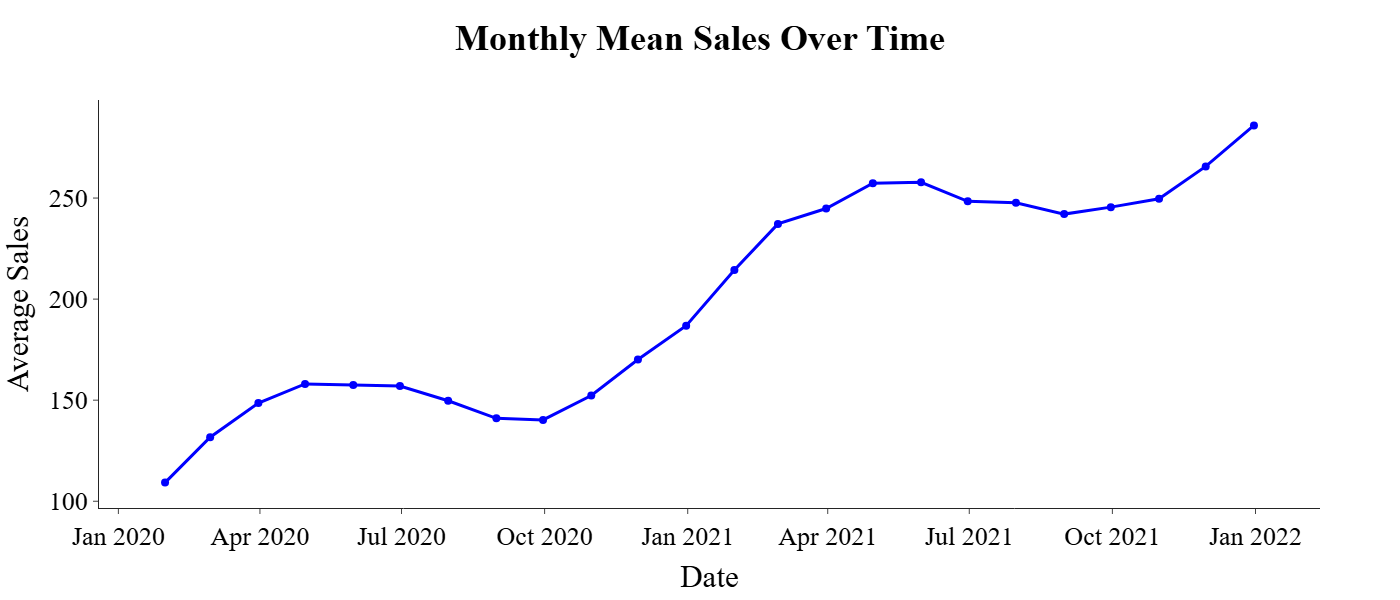

In [3]:
ts_plots.plot_time_series_mean(
    data=ts_data,
    feature='date',
    target='sales',
    agg_freq='ME',
    plot_title="Monthly Mean Sales Over Time",
    width=1400,
    height=600,
    xaxis_title="Date",
    yaxis_title="Average Sales",
    line_color="blue",
    line_width=3,
    show_markers=True,
    marker_size=8
)

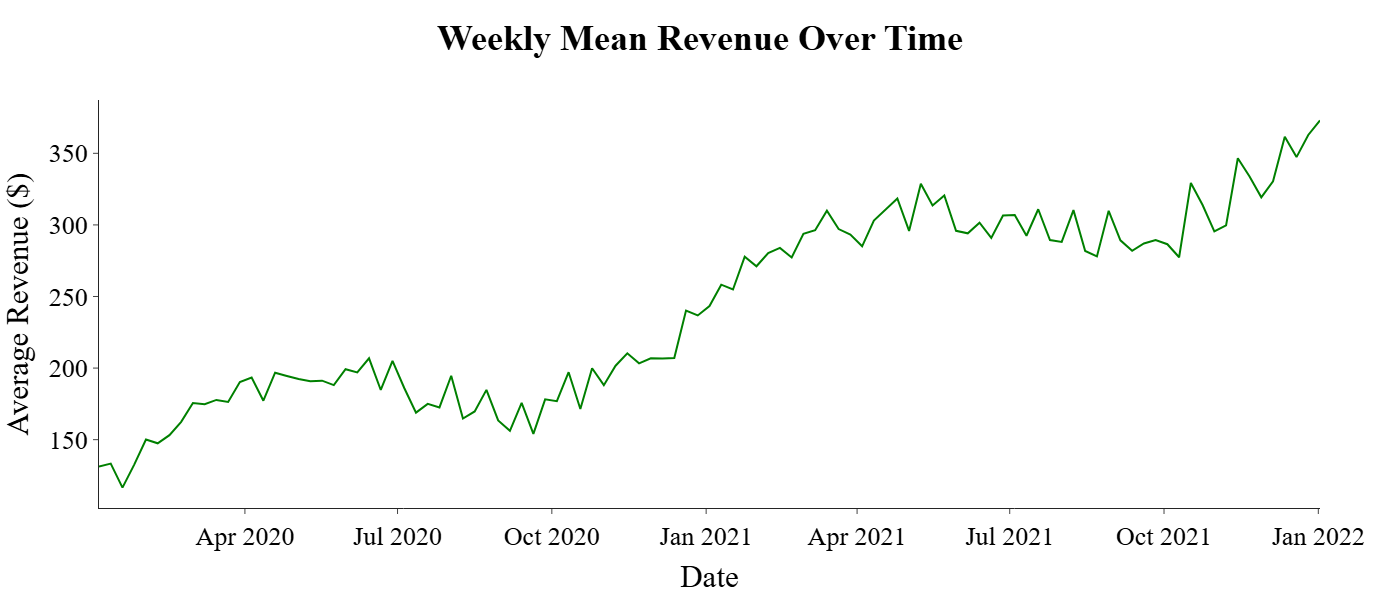

In [4]:
ts_plots.plot_time_series_mean(
    data=ts_data,
    feature='date',
    target='revenue',
    agg_freq='W',
    plot_title="Weekly Mean Revenue Over Time",
    width=1400,
    height=600,
    xaxis_title="Date",
    yaxis_title="Average Revenue ($)",
    line_color="green",
    line_width=2,
    show_markers=False
)

## 2. plot_time_series_multiple_metrics() - Multiple Time Series

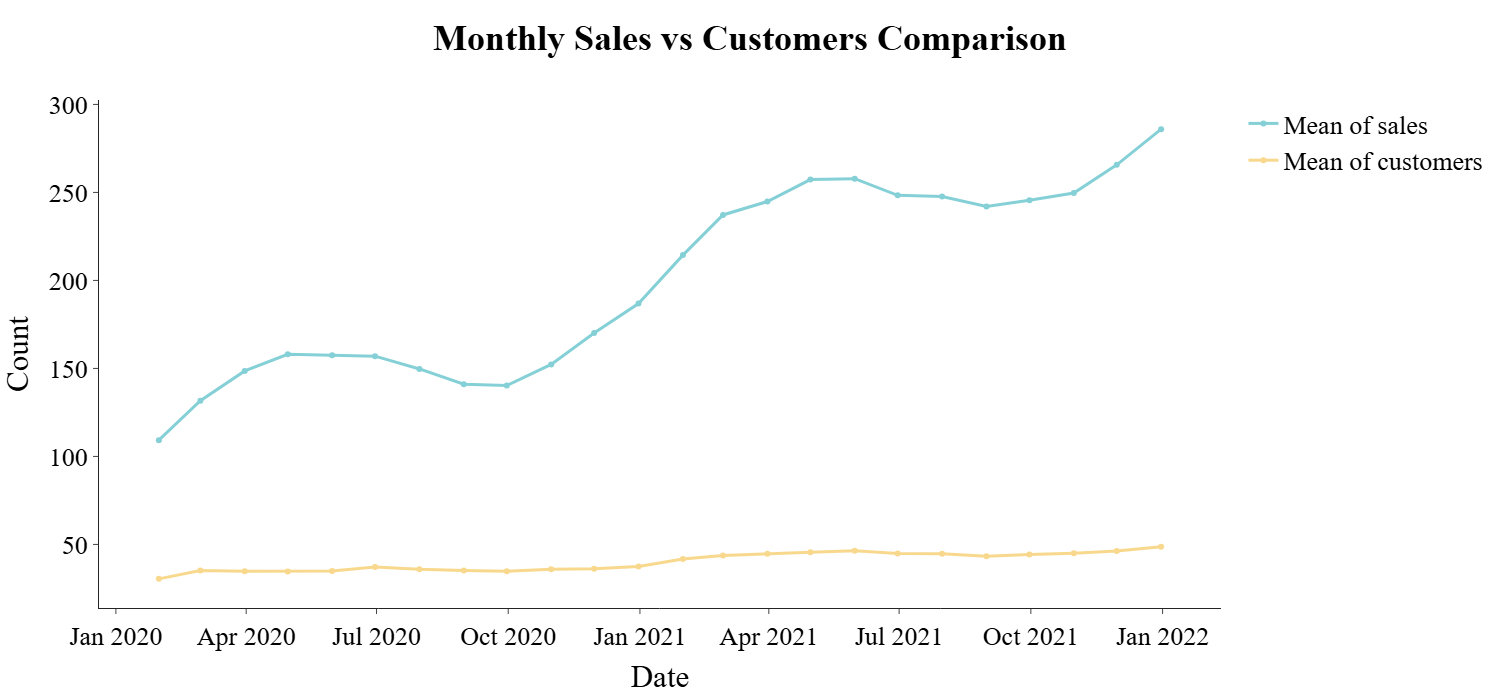

In [5]:
ts_plots.plot_time_series_multiple_metrics(
    data=ts_data,
    feature='date',
    targets=['sales', 'customers'],
    agg_freq='ME',
    agg_func='mean',
    plot_title="Monthly Sales vs Customers Comparison",
    width=1500,
    height=700,
    xaxis_title="Date",
    yaxis_title="Count",
    show_markers=True,
    marker_size=6,
    line_width=3,
    show_legend=True,
    opacity=0.8
)

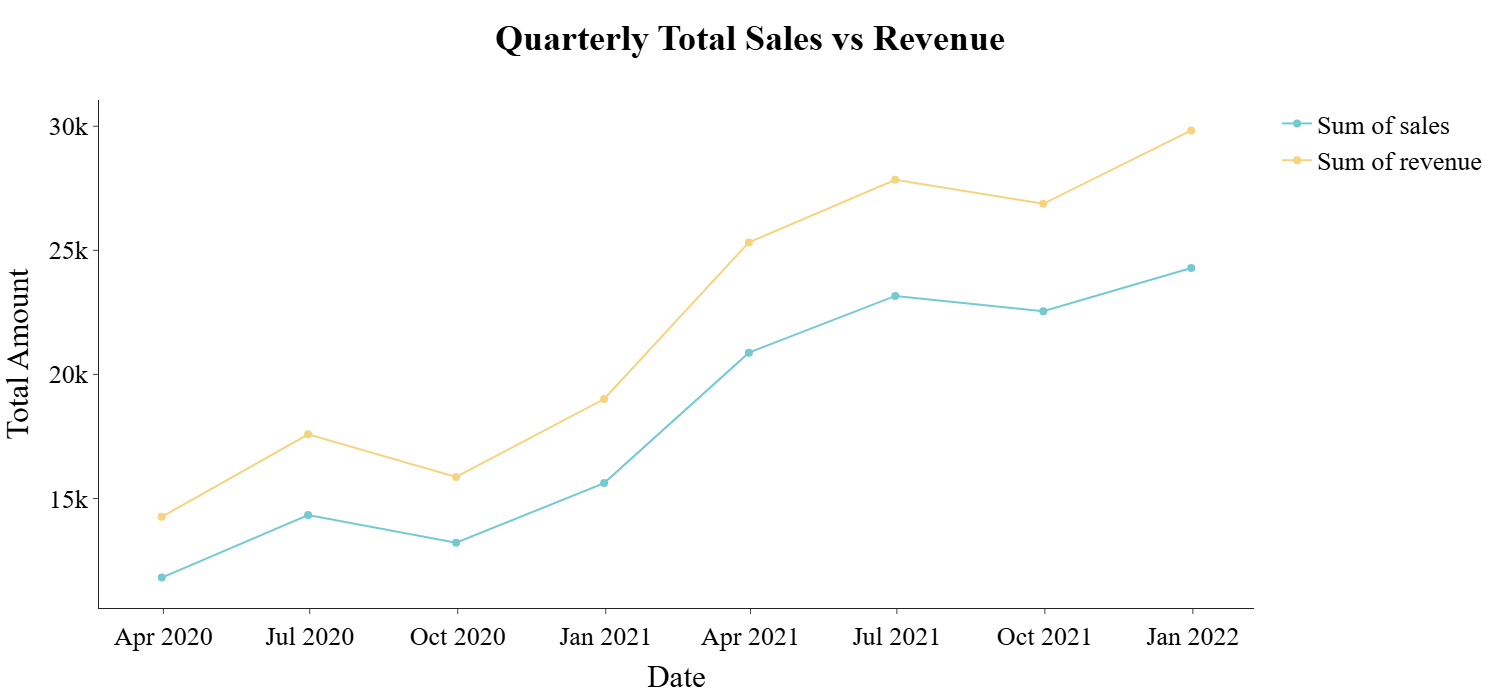

In [6]:
ts_plots.plot_time_series_multiple_metrics(
    data=ts_data,
    feature='date',
    targets=['sales', 'revenue'],
    agg_freq='QE',
    agg_func='sum',
    plot_title="Quarterly Total Sales vs Revenue",
    width=1500,
    height=700,
    xaxis_title="Date",
    yaxis_title="Total Amount",
    show_markers=True,
    marker_size=8,
    line_width=2,
    show_legend=True,
    opacity=0.9
)

## 3. plot_time_series_with_trend() - Time Series with Moving Average Trend

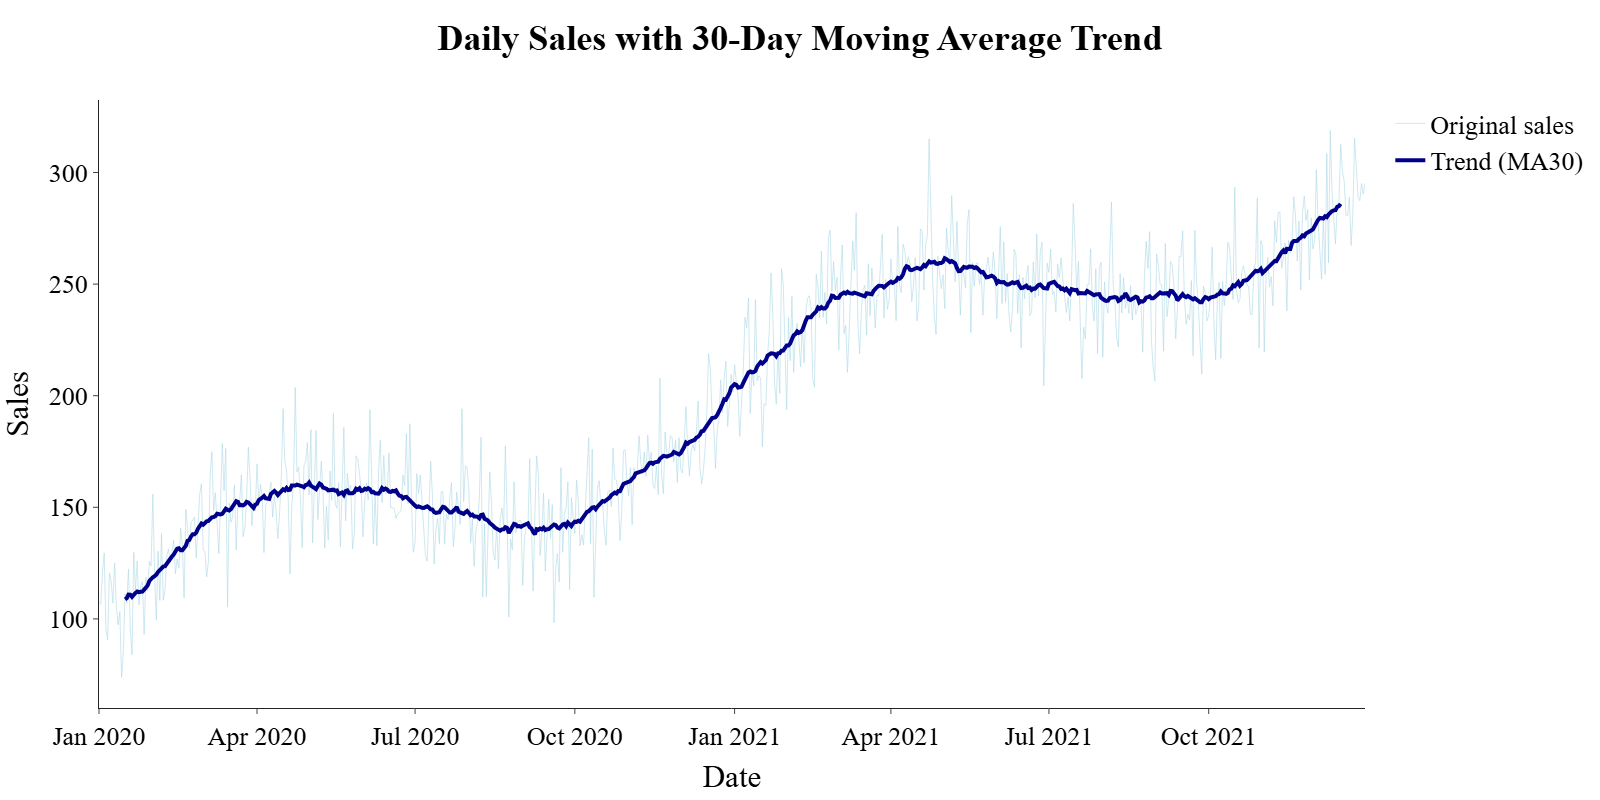

In [7]:
ts_plots.plot_time_series_with_trend(
    data=ts_data,
    feature='date',
    target='sales',
    window_size=30,
    plot_title="Daily Sales with 30-Day Moving Average Trend",
    width=1600,
    height=800,
    xaxis_title="Date",
    yaxis_title="Sales",
    original_color="lightblue",
    trend_color="darkblue",
    original_opacity=0.6,
    trend_line_width=4,
    original_line_width=1,
    show_legend=True,
    trend_mode="lines"
)

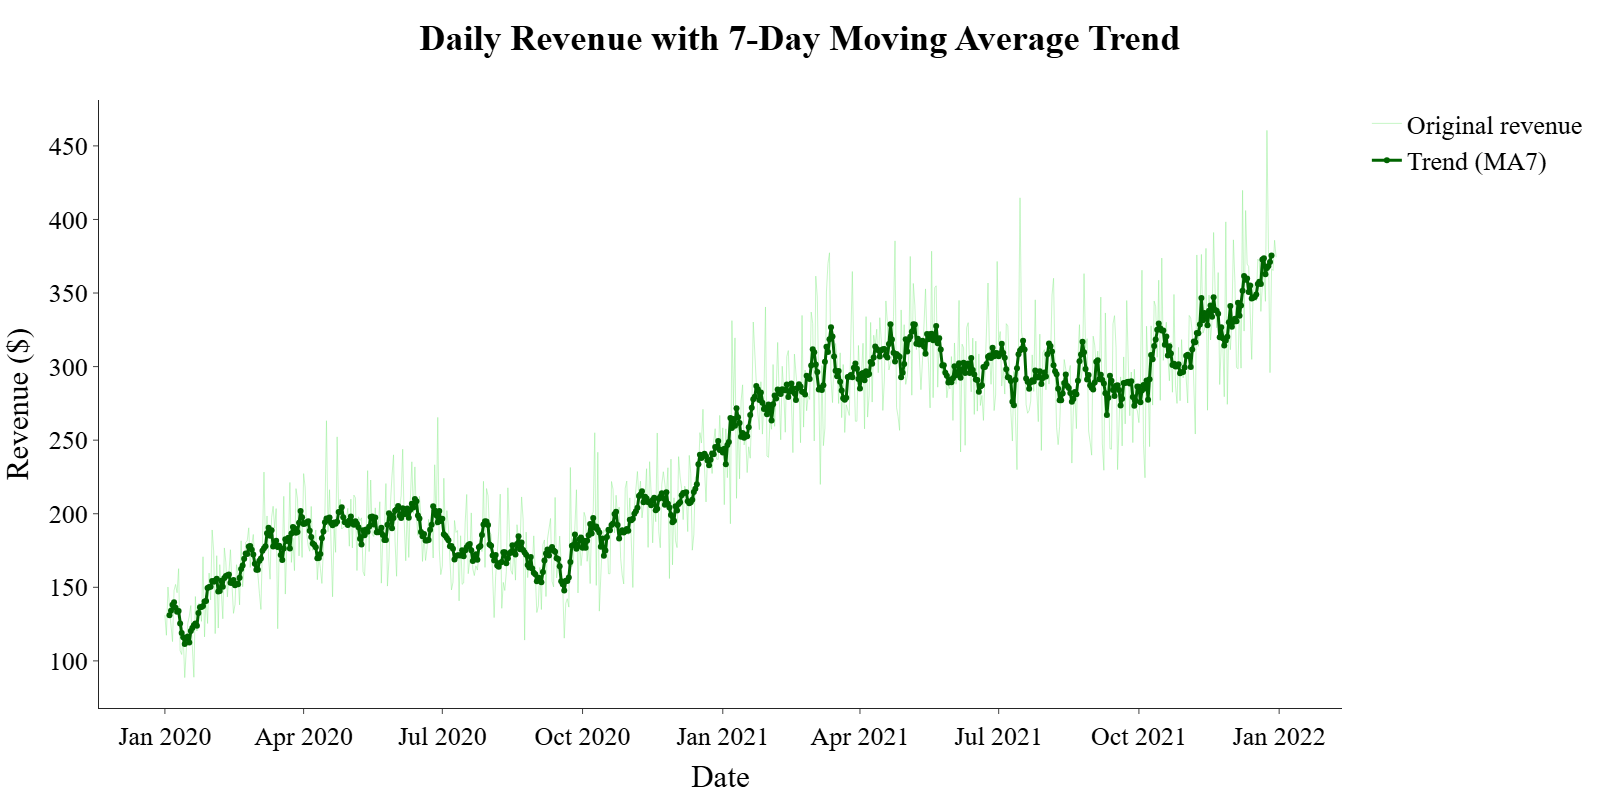

In [8]:
ts_plots.plot_time_series_with_trend(
    data=ts_data,
    feature='date',
    target='revenue',
    window_size=7,
    plot_title="Daily Revenue with 7-Day Moving Average Trend",
    width=1600,
    height=800,
    xaxis_title="Date",
    yaxis_title="Revenue ($)",
    original_color="lightgreen",
    trend_color="darkgreen",
    original_opacity=0.5,
    trend_line_width=3,
    original_line_width=1,
    show_legend=True,
    trend_mode="lines+markers"
)

## 4. plot_seasonal_decomposition() - Seasonal Decomposition Analysis

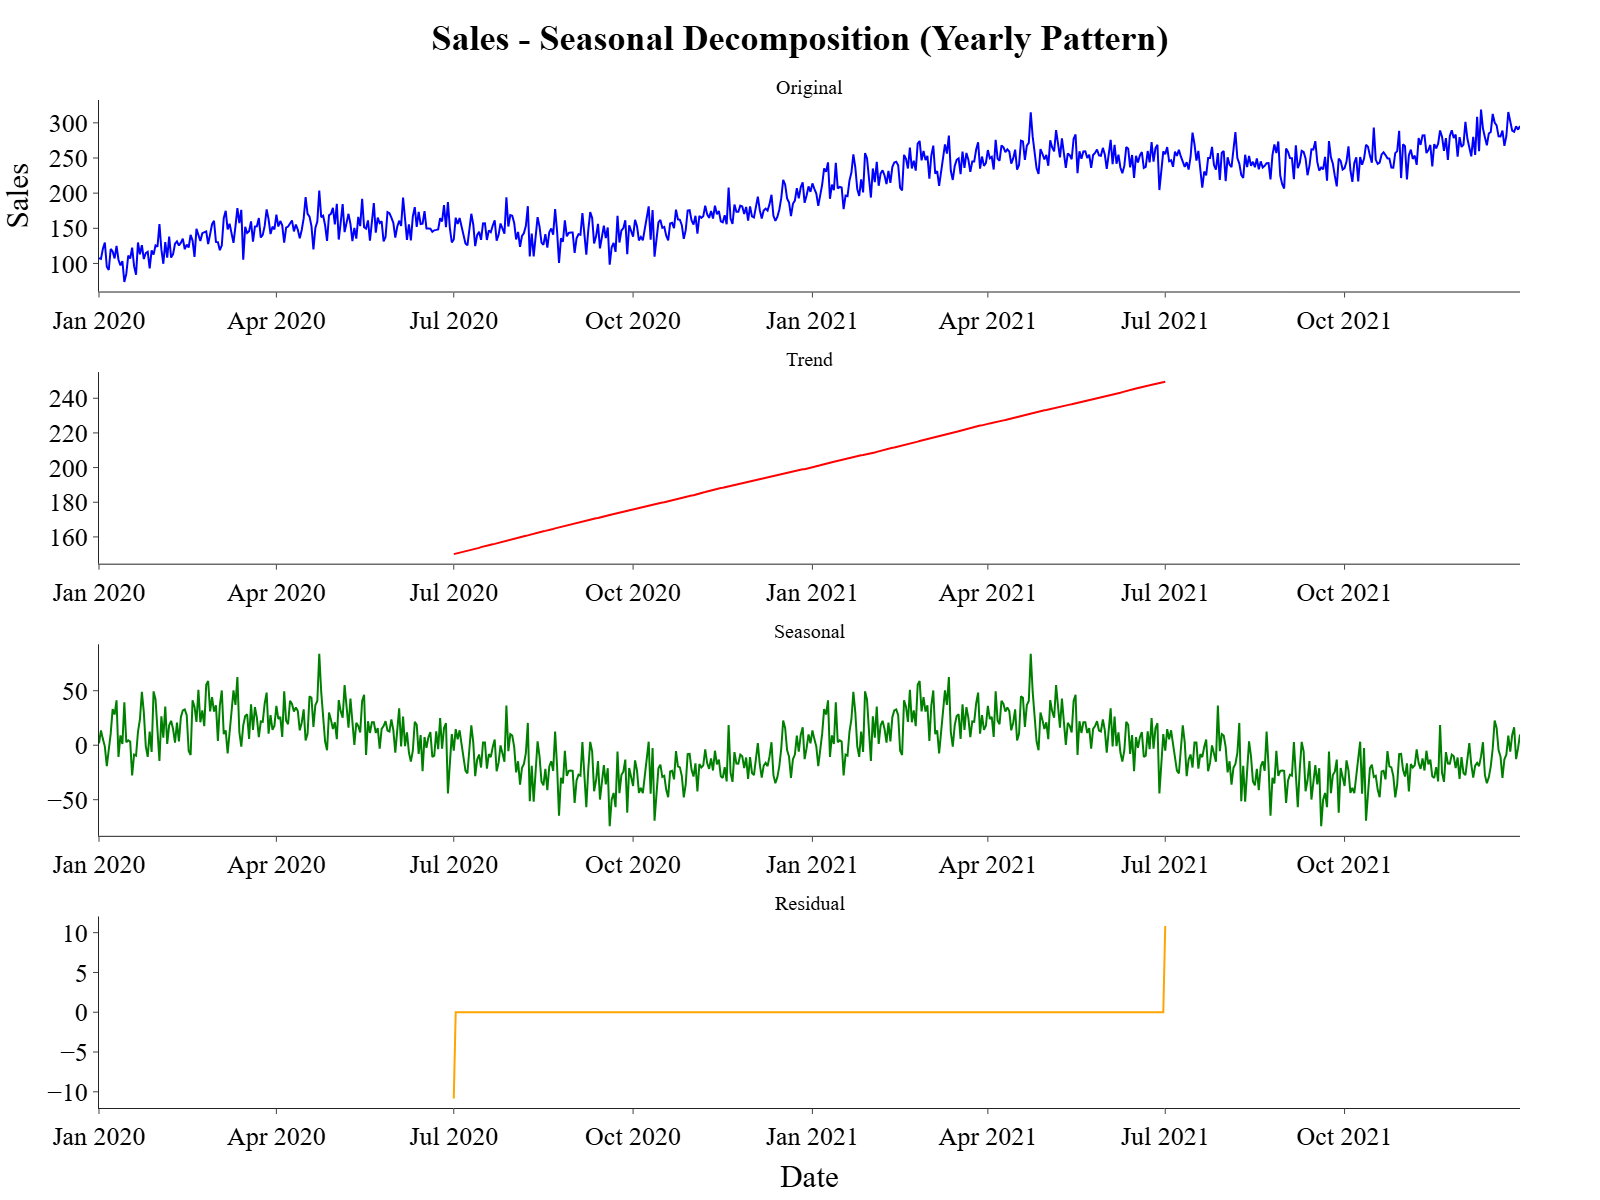

In [9]:
ts_plots.plot_seasonal_decomposition(
    data=ts_data,
    feature='date',
    target='sales',
    freq=365,  # Yearly seasonality
    plot_title="Sales - Seasonal Decomposition (Yearly Pattern)",
    width=1600,
    height=1200,
    xaxis_title="Date",
    yaxis_title="Sales",
    original_color="blue",
    trend_color="red",
    seasonal_color="green",
    residual_color="orange",
    line_width=2,
    show_subplot_titles=True,
    vertical_spacing=0.08
)

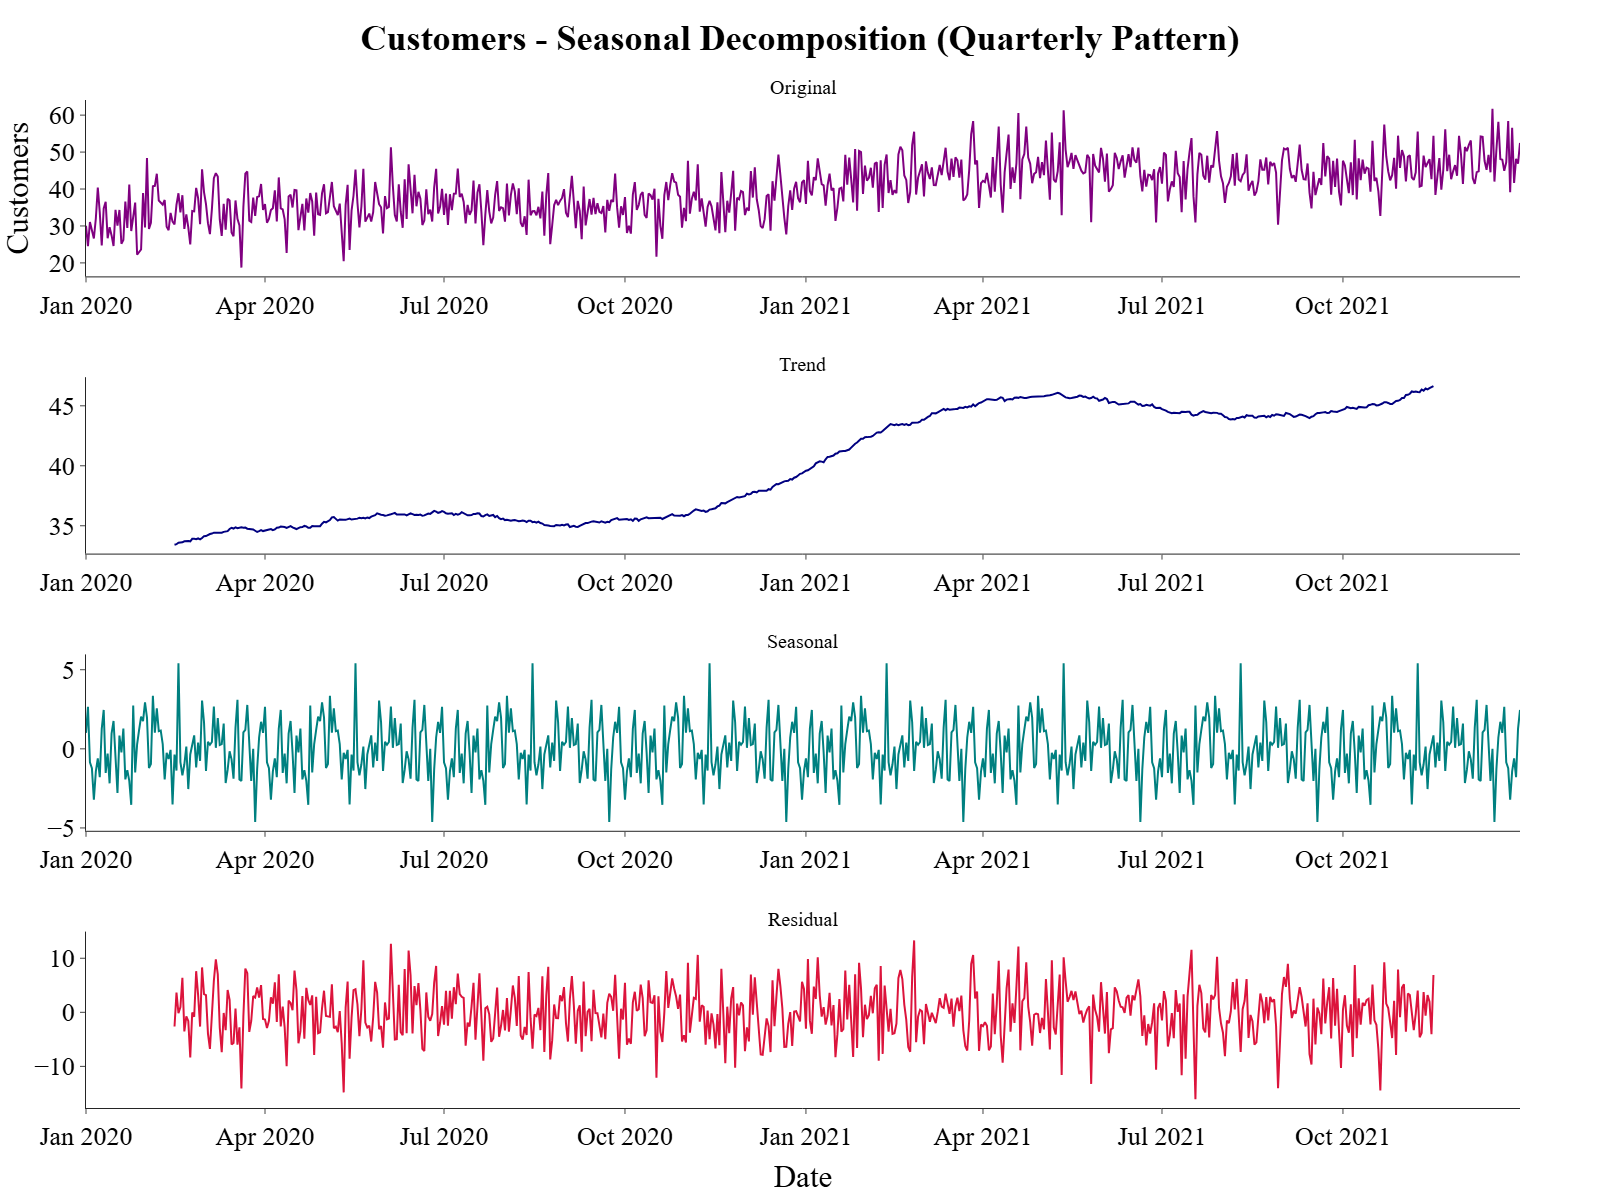

In [10]:
ts_plots.plot_seasonal_decomposition(
    data=ts_data,
    feature='date',
    target='customers',
    freq=90,  # Quarterly seasonality
    plot_title="Customers - Seasonal Decomposition (Quarterly Pattern)",
    width=1600,
    height=1200,
    xaxis_title="Date",
    yaxis_title="Customers",
    original_color="purple",
    trend_color="navy",
    seasonal_color="teal",
    residual_color="crimson",
    line_width=2,
    show_subplot_titles=True,
    vertical_spacing=0.1
)